# Robustness Experiments: BN vs MRF Under Missing Evidence

This notebook investigates how Bayesian Networks (BN) and Markov Random Fields (MRF) respond when clinical features are withheld at inference time — simulating real-world scenarios where not all tests are available for a patient.

**A key theoretical distinction:**
- **BN (directed)**: evidence propagates only along DAG paths; removing a node breaks information flow through those paths.
- **MRF (undirected)**: evidence is distributed through all neighbouring factors simultaneously; the undirected structure may compensate via alternative paths.

**Research questions:**
1. How much does AUC degrade when individual features are removed?
2. Do BN and MRF degrade differently — and does the gap persist for the best variants?
3. Which clinical feature groups are most critical for each model family?
4. Does predictive entropy increase appropriately when evidence is withheld?

**Models compared:**

| Model | Family | Description |
|-------|--------|-------------|
| Base BN | BN | 13-edge star DAG, BDeu prior (equivalent sample size = 10) |
| Best BN | BN | 17-edge hill-climbing learned DAG, BDeu prior |
| Base MRF | MRF | 13-edge undirected graph, α=1.0, γ=0.0 |
| Best MRF | MRF | 13-edge undirected graph, α=10.0, γ=1.5 (MI-reweighted potentials) |

In [1]:
import pandas as pd
from IPython.display import display

from robustness_utils import (
    ALL_SINGLE_FEATURE_REMOVAL,
    BASELINE_METRICS,
    CLINICAL_GROUP_REMOVAL,
    compute_within_family_improvement,
    get_model_specs,
    load_discretized_heart_data,
    model_definition_table,
    plot_group_bars,
    plot_single_feature_heatmap,
    plot_within_family_group_bars,
    plot_within_family_single_heatmap,
    run_full_baseline,
    run_missing_scenarios,
    summarize_baseline_results,
    summarize_improvements,
    summarize_scenario_results,
)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)


d:\Tools\anaconda3\envs\CS5340\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_disc = load_discretized_heart_data("heart_disease_cleaned.csv")
model_specs = get_model_specs()

print(f"Loaded discretized dataset: {df_disc.shape[0]} rows x {df_disc.shape[1]} cols")
print("Class balance:")
display(df_disc["num"].value_counts(normalize=True).rename("proportion").sort_index().to_frame())

print("Model definitions:")
display(model_definition_table())


Loaded discretized dataset: 303 rows x 14 cols
Class balance:


,proportion
num,
0,0.541254
1,0.458746


Model definitions:


,model,family,level,description
0,Base BN,BN,Base,Original 13-edge DAG with BDeu parameter learning
1,Best BN,BN,Best,Hill-climbing learned DAG with BDeu parameter ...
2,Base MRF,MRF,Base,Original 13-edge undirected graph with alpha=1...
3,Best MRF,MRF,Best,Tuned 13-edge undirected graph with alpha=10.0...


## 1. Full-Evidence Baseline

Establish each model's performance with all 13 features observed. These values are the reference against which all missing-evidence degradation is measured.

In [3]:
baseline_df = run_full_baseline(df_disc, model_specs=model_specs)
baseline_summary = summarize_baseline_results(baseline_df)

display(baseline_summary[BASELINE_METRICS])


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N

,auc,brier,log_loss,ece,mean_entropy,mean_variance
model,,,,,,
Base BN,0.8955,0.1506,0.5470,0.1428,0.2812,0.0594
Base MRF,0.9115,0.1533,0.6193,0.1702,0.2495,0.0515
Best BN,0.9158,0.1181,0.3897,0.1023,0.4179,0.0878
Best MRF,0.9157,0.1574,0.8630,0.1740,0.1584,0.0329


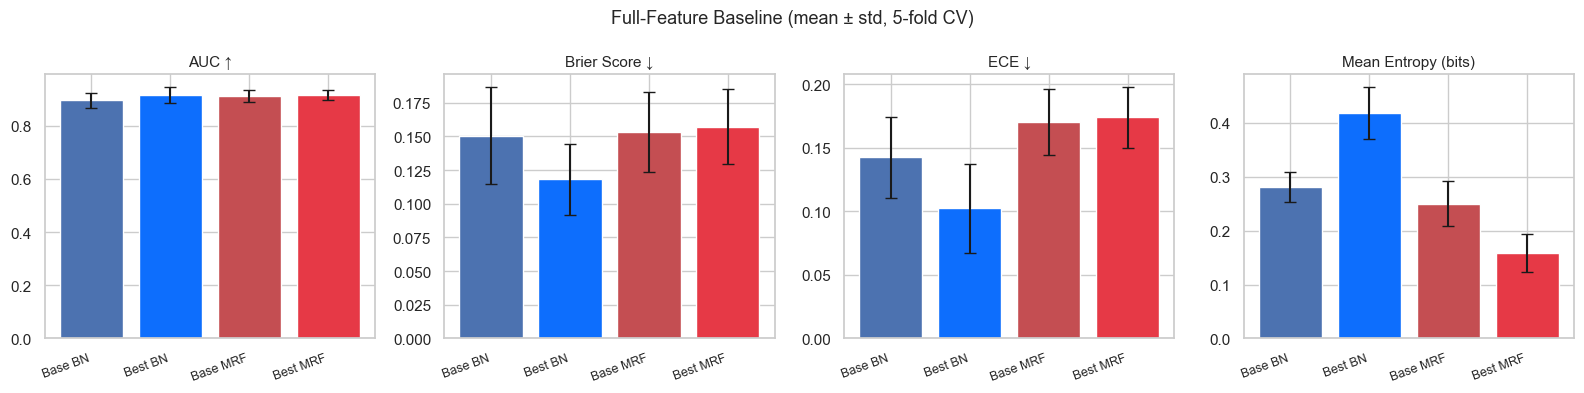

In [4]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {'Base BN': '#4C72B0', 'Best BN': '#0d6efd', 'Base MRF': '#C44E52', 'Best MRF': '#e63946'}
MODEL_ORDER = ['Base BN', 'Best BN', 'Base MRF', 'Best MRF']

metrics_to_plot = ['auc', 'brier', 'ece', 'mean_entropy']
labels = {'auc': 'AUC ↑', 'brier': 'Brier Score ↓', 'ece': 'ECE ↓', 'mean_entropy': 'Mean Entropy (bits)'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metrics_to_plot):
    means = baseline_df.groupby('model')[metric].mean().reindex(MODEL_ORDER)
    stds  = baseline_df.groupby('model')[metric].std().reindex(MODEL_ORDER)
    ax.bar(MODEL_ORDER, means, yerr=stds, capsize=4,
           color=[COLORS[m] for m in MODEL_ORDER], edgecolor='white')
    ax.set_title(labels[metric], fontsize=11)
    ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right', fontsize=9)

fig.suptitle('Full-Feature Baseline (mean ± std, 5-fold CV)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Experiment A — Single-Feature Removal

Each of the 13 features is removed one at a time. This reveals which individual features each model depends on most, and whether BN and MRF are differentially sensitive to the same features.

**Expected findings:**
- Removing `ca` or `thal` (strongest predictors, r=0.52/0.51) should cause the largest AUC drop.
- BN: in the Base DAG, every feature connects directly to `num` (as risk factor) or from `num` (as symptom); removing a feature removes exactly one edge. In the Best BN the learned structure creates multi-hop paths, which may offer more resilience.
- MRF: the undirected structure distributes evidence through all factor neighbours; removing one node may be partially compensated.
- Predictive entropy should increase after removing any feature.

In [5]:
single_df = run_missing_scenarios(
    df_disc,
    ALL_SINGLE_FEATURE_REMOVAL,
    experiment_name="single_feature",
    model_specs=model_specs,
)

single_summary = summarize_scenario_results(single_df)
single_key_cols = [
    "auc",
    "auc_drop",
    "brier_increase",
    "ece_increase",
    "delta_entropy",
    "delta_prob_abs",
]

display(single_summary[single_key_cols])


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N

auc  auc_drop  brier_increase  ece_increase  \
scenario      model                                                      
drop_age      Base BN   0.9077    0.0122         -0.0217       -0.0213   
              Base MRF  0.9120    0.0004         -0.0017       -0.0049   
              Best BN   0.9158    0.0000          0.0000        0.0000   
              Best MRF  0.9133   -0.0024         -0.0009       -0.0052   
drop_ca       Base BN   0.8698   -0.0257          0.0163        0.0117   
              Base MRF  0.8881   -0.0235          0.0318        0.0388   
              Best BN   0.8887   -0.0271          0.0191        0.0112   
              Best MRF  0.8888   -0.0269          0.0369        0.0416   
drop_chol     Base BN   0.9119    0.0164         -0.0171        0.0006   
              Base MRF  0.9116    0.0001         -0.0006       -0.0147   
              Best BN   0.9158    0.0000          0.0000        0.0000   
              Best MRF  0.9158    0.0001         -0.0009       -0.0055   
drop_cp       Base BN   0.8743   -0.0212          0.0174        0.0182   
              Base MRF  0.8978   -0.0138          0.0037        0.0051   
              Best BN   0.8995   -0.0163          0.0108        0.0045   
              Best MRF  0.8999   -0.0159         -0.0000        0.0004   
drop_exang    Base BN   0.8884   -0.0071          0.0036        0.0155   
              Base MRF  0.9080   -0.0035          0.0155        0.0190   
              Best BN   0.9098   -0.0061          0.0014        0.0050   
              Best MRF  0.9145   -0.0012          0.0153        0.0194   
drop_fbs      Base BN   0.9028    0.0073         -0.0079       -0.0018   
              Base MRF  0.9122    0.0007         -0.0001       -0.0012   
              Best BN   0.9158    0.0000          0.0000        0.0000   
              Best MRF  0.9164    0.0006         -0.0001       -0.0005   
drop_oldpeak  Base BN   0.8899   -0.0056          0.0027        0.0134   
              Base MRF  0.9110   -0.0005          0.0070       -0.0026   
              Best BN   0.9131   -0.0028         -0.0026        0.0123   
              Best MRF  0.9147   -0.0010          0.0074        0.0051   
drop_restecg  Base BN   0.8939   -0.0017         -0.0021        0.0076   
              Base MRF  0.9103   -0.0012         -0.0010        0.0007   
              Best BN   0.9158    0.0000          0.0000        0.0000   
              Best MRF  0.9143   -0.0015         -0.0009       -0.0049   
drop_sex      Base BN   0.8890   -0.0065         -0.0034        0.0060   
              Base MRF  0.9061   -0.0055         -0.0003       -0.0014   
              Best BN   0.9108   -0.0050          0.0011       -0.0044   
              Best MRF  0.9114   -0.0044         -0.0018       -0.0040   
drop_slope    Base BN   0.8907   -0.0049          0.0029        0.0037   
              Base MRF  0.9127    0.0011          0.0053        0.0032   
              Best BN   0.9158    0.0000          0.0000        0.0000   
              Best MRF  0.9148   -0.0009          0.0064        0.0066   
drop_thal     Base BN   0.8778   -0.0178          0.0101        0.0046   
              Base MRF  0.8969   -0.0146          0.0234        0.0268   
              Best BN   0.8979   -0.0180          0.0102        0.0026   
              Best MRF  0.8988   -0.0169          0.0328        0.0322   
drop_thalach  Base BN   0.8963    0.0008          0.0000        0.0053   
              Base MRF  0.9165    0.0050          0.0021        0.0007   
              Best BN   0.9200    0.0042         -0.0023        0.0046   
              Best MRF  0.9165    0.0008          0.0009        0.0038   
drop_trestbps Base BN   0.9075    0.0120         -0.0119       -0.0156   
              Base MRF  0.9111   -0.0005         -0.0011       -0.0039   
              Best BN   0.9158    0.0000          0.0000        0.0000   
              Best MRF  0.9157   -0.0000         -0.0010        0.0019   

                        delta_

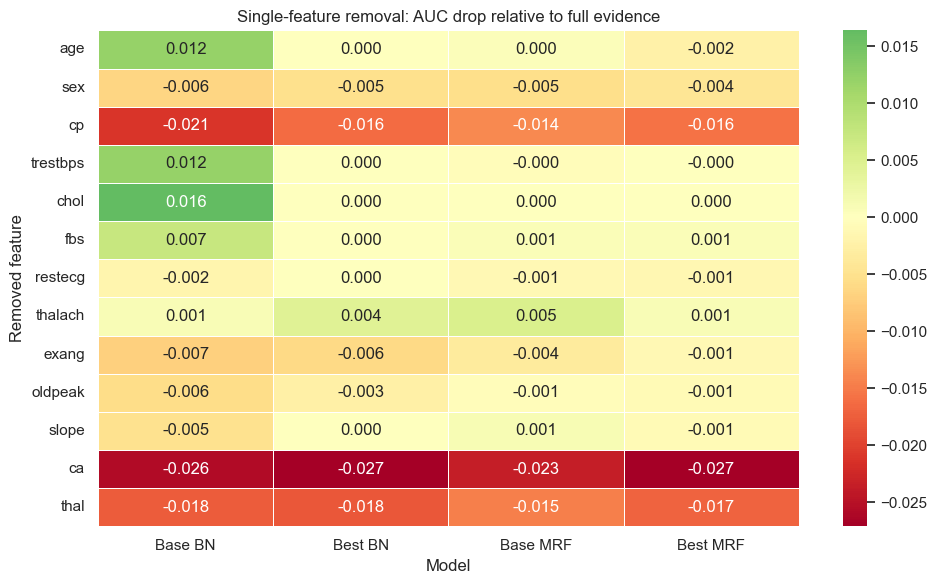

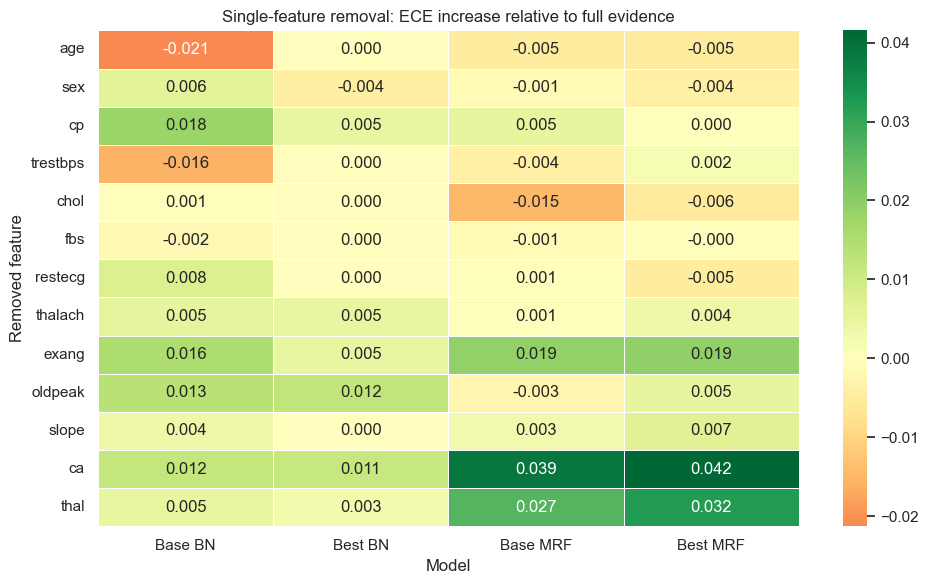

In [6]:
plot_single_feature_heatmap(
    single_df,
    value_col="auc_drop",
    title="Single-feature removal: AUC drop relative to full evidence",
)

plot_single_feature_heatmap(
    single_df,
    value_col="ece_increase",
    title="Single-feature removal: ECE increase relative to full evidence",
)


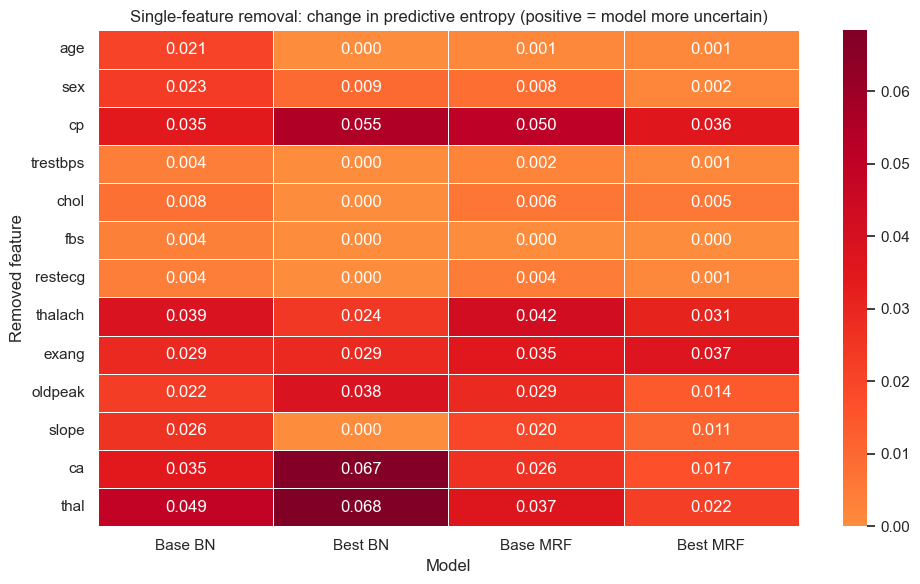

In [7]:
from robustness_utils import plot_single_feature_heatmap

plot_single_feature_heatmap(
    single_df,
    value_col="delta_entropy",
    title="Single-feature removal: change in predictive entropy (positive = model more uncertain)",
    cmap="YlOrRd",
    center=0.0,
)

## 3. Experiment B — Clinical Group Removal

Real clinical workflows often omit entire test categories. Four clinically motivated groups are tested:

| Scenario | Features removed | Clinical meaning |
|----------|-----------------|------------------|
| `drop_risk_factors` | age, sex, fbs, chol, trestbps | No demographic/background info |
| `drop_exercise_ecg` | restecg, thalach, exang, oldpeak, slope | No exercise stress test |
| `drop_imaging_perf` | ca, thal | No imaging/perfusion data |
| `drop_all_diagnostics` | cp, restecg, thalach, exang, oldpeak, slope, ca, thal | Demographics only |

`drop_imaging_perf` removes `ca` and `thal` (the two strongest individual predictors), so it should cause the largest degradation.

In [8]:
group_df = run_missing_scenarios(
    df_disc,
    CLINICAL_GROUP_REMOVAL,
    experiment_name="clinical_group",
    model_specs=model_specs,
)

group_summary = summarize_scenario_results(group_df)
group_key_cols = [
    "auc",
    "auc_drop",
    "brier_increase",
    "ece_increase",
    "delta_entropy",
    "delta_prob_abs",
]

display(group_summary[group_key_cols])


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N

auc  auc_drop  brier_increase  ece_increase  \
scenario             model                                                      
drop_all_diagnostics Base BN   0.6330   -0.2625          0.1101        0.0575   
                     Base MRF  0.6963   -0.2153          0.2679        0.2535   
                     Best BN   0.7121   -0.2037          0.1015        0.0122   
                     Best MRF  0.6937   -0.2220          0.2966        0.2805   
drop_exercise_ecg    Base BN   0.8648   -0.0307          0.0148        0.0060   
                     Base MRF  0.9008   -0.0107          0.0904        0.1112   
                     Best BN   0.9082   -0.0077          0.0078       -0.0010   
                     Best MRF  0.9014   -0.0143          0.0972        0.1031   
drop_imaging_perf    Base BN   0.8480   -0.0475          0.0276        0.0268   
                     Base MRF  0.8695   -0.0420          0.0619        0.0663   
                     Best BN   0.8635   -0.0523          0.0337        0.0139   
                     Best MRF  0.8684   -0.0473          0.0811        0.0850   
drop_risk_factors    Base BN   0.9062    0.0106         -0.0214       -0.0182   
                     Base MRF  0.9055   -0.0060         -0.0046       -0.0128   
                     Best BN   0.9108   -0.0050          0.0011       -0.0044   
                     Best MRF  0.9086   -0.0072         -0.0049       -0.0112   

                               delta_entropy  delta_prob_abs  
scenario             model                                    
drop_all_diagnostics Base BN          0.4574          0.3110  
                     Base MRF        -0.0413          0.3153  
                     Best BN          0.5195          0.3258  
                     Best MRF        -0.1202          0.3324  
drop_exercise_ecg    Base BN          0.1638          0.1381  
                     Base MRF         0.1081          0.1844  
                     Best BN          0.1177          0.1054  
                     Best MRF         0.0613          0.1765  
drop_imaging_perf    Base BN          0.0902          0.0911  
                     Base MRF         0.0632          0.1091  
                     Best BN          0.1379          0.1222  
                     Best MRF         0.0436          0.1317  
drop_risk_factors    Base BN          0.0359          0.0749  
                     Base MRF         0.0200          0.0274  
                     Best BN          0.0093          0.0264  
                     Best MRF         0.0114          0.0163

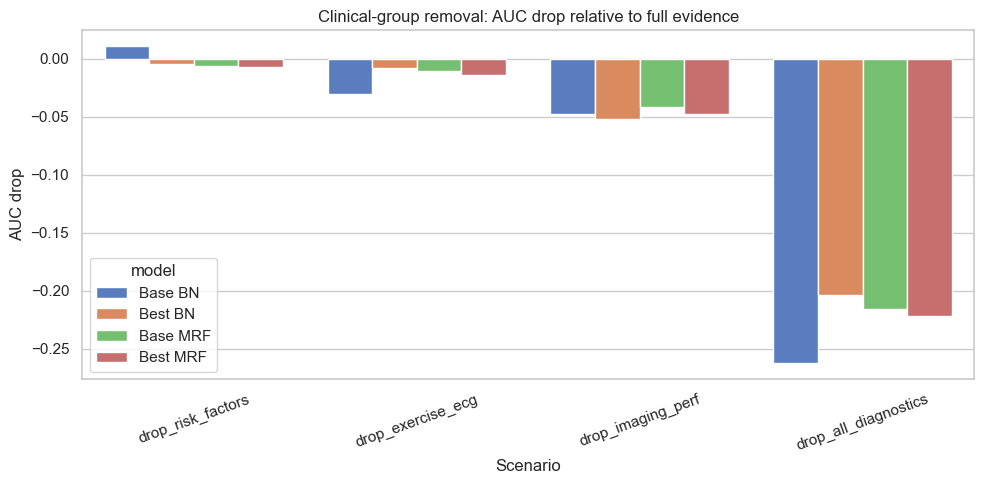

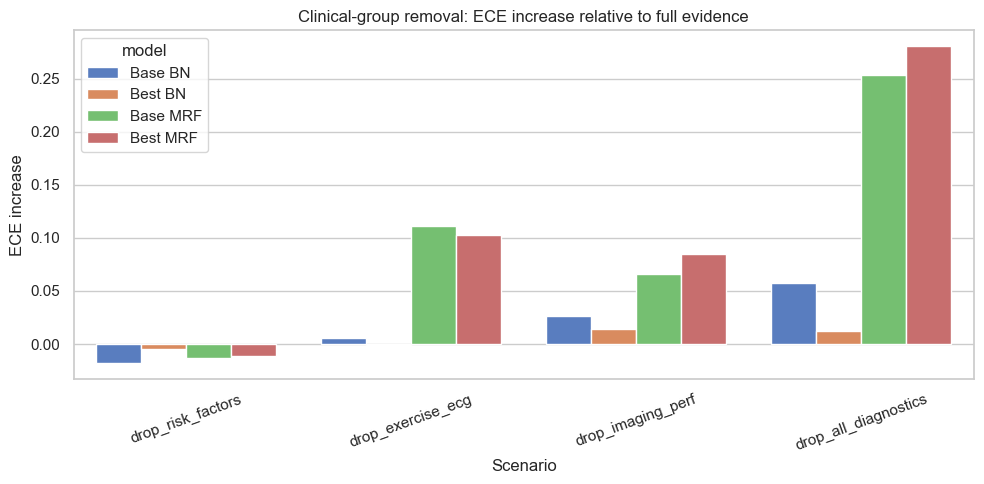

In [9]:
plot_group_bars(
    group_df,
    value_col="auc_drop",
    title="Clinical-group removal: AUC drop relative to full evidence",
    ylabel="AUC drop",
)

plot_group_bars(
    group_df,
    value_col="ece_increase",
    title="Clinical-group removal: ECE increase relative to full evidence",
    ylabel="ECE increase",
)


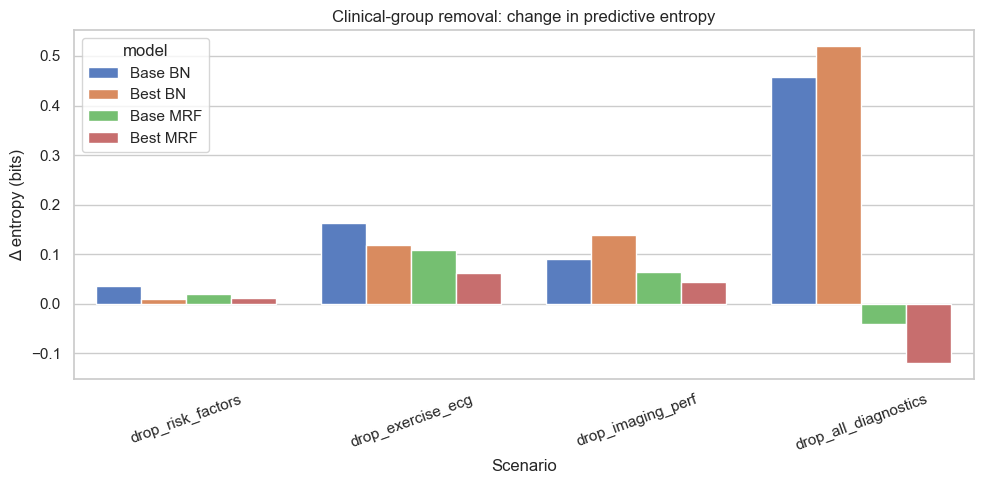

In [10]:
from robustness_utils import plot_group_bars

plot_group_bars(
    group_df,
    value_col="delta_entropy",
    title="Clinical-group removal: change in predictive entropy",
    ylabel="Δ entropy (bits)",
)

## 4. BN vs MRF: Directed vs Undirected Under Missing Evidence

Directly compare Base BN and Base MRF (identical 13-edge graph topology, different parameterisation) to isolate the effect of directionality.

In [11]:
improvement_df = compute_within_family_improvement(
    pd.concat([single_df, group_df], ignore_index=True)
)
improvement_summary = summarize_improvements(improvement_df)

improvement_key_cols = [
    "auc_gain",
    "ece_gain",
    "auc_drop_gain",
    "ece_robust_gain",
    "delta_prob_reduction",
]

display(improvement_summary[improvement_key_cols])


auc_gain  ece_gain  auc_drop_gain  \
experiment     scenario             family                                      
clinical_group drop_all_diagnostics BN        0.0791    0.0858         0.0588   
                                    MRF      -0.0026   -0.0308        -0.0068   
               drop_exercise_ecg    BN        0.0434    0.0475         0.0230   
                                    MRF       0.0006    0.0043        -0.0036   
               drop_imaging_perf    BN        0.0155    0.0534        -0.0048   
                                    MRF      -0.0012   -0.0225        -0.0053   
               drop_risk_factors    BN        0.0046    0.0266        -0.0157   
                                    MRF       0.0031   -0.0053        -0.0011   
single_feature drop_age             BN        0.0081    0.0191        -0.0122   
                                    MRF       0.0013   -0.0035        -0.0029   
               drop_ca              BN        0.0189    0.0409        -0.0014   
                                    MRF       0.0007   -0.0066        -0.0035   
               drop_chol            BN        0.0040    0.0410        -0.0164   
                                    MRF       0.0042   -0.0129         0.0000   
               drop_cp              BN        0.0252    0.0541         0.0049   
                                    MRF       0.0021    0.0009        -0.0021   
               drop_exang           BN        0.0214    0.0510         0.0011   
                                    MRF       0.0065   -0.0042         0.0023   
               drop_fbs             BN        0.0130    0.0386        -0.0073   
                                    MRF       0.0042   -0.0045        -0.0000   
               drop_oldpeak         BN        0.0231    0.0416         0.0028   
                                    MRF       0.0037   -0.0115        -0.0005   
               drop_restecg         BN        0.0220    0.0480         0.0017   
                                    MRF       0.0040    0.0018        -0.0002   
               drop_sex             BN        0.0218    0.0508         0.0015   
                                    MRF       0.0053   -0.0011         0.0011   
               drop_slope           BN        0.0252    0.0441         0.0049   
                                    MRF       0.0022   -0.0072        -0.0020   
               drop_thal            BN        0.0201    0.0424        -0.0002   
                                    MRF       0.0019   -0.0091        -0.0023   
               drop_thalach         BN        0.0237    0.0411         0.0034   
                                    MRF       0.0000   -0.0069        -0.0042   
               drop_trestbps        BN        0.0083    0.0248        -0.0120   
                                    MRF       0.0046   -0.0096         0.0005   

                                            ece_robust_gain  \
experiment     scenario             family                    
clinical_group drop_all_diagnostics BN               0.0454   
                                    MRF             -0.0270   
               drop_exercise_ecg    BN               0.0070   
                                    MRF              0.0081   
               drop_imaging_perf    BN               0.0129   
                                    MRF             -0.0187   
               drop_risk_factors    BN              -0.0138   
                                    MRF             -0.0015   
single_feature drop_age             BN              -0.0213   
                                    MRF              0.0003   
               drop_ca              BN               0.0005   
                                    MRF             -0.0028   
               drop_chol            BN               0.0006   
                                    MRF             -0.0092   
               drop_cp              BN               0.0137   
                                    MRF              0.0

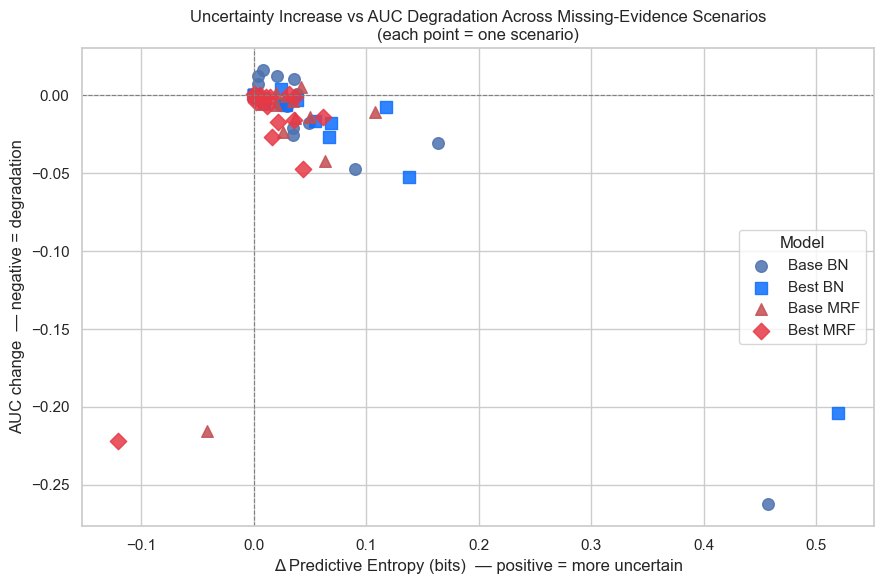

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Scatter: AUC drop vs entropy increase per scenario, coloured by model
all_results = pd.concat([single_df, group_df], ignore_index=True)

scenario_means = (
    all_results.groupby(['model', 'scenario'])[['auc_drop', 'delta_entropy']]
    .mean()
    .reset_index()
)

COLORS = {'Base BN': '#4C72B0', 'Best BN': '#0d6efd', 'Base MRF': '#C44E52', 'Best MRF': '#e63946'}
markers = {'Base BN': 'o', 'Best BN': 's', 'Base MRF': '^', 'Best MRF': 'D'}
MODEL_ORDER = ['Base BN', 'Best BN', 'Base MRF', 'Best MRF']

fig, ax = plt.subplots(figsize=(9, 6))
for model in MODEL_ORDER:
    sub = scenario_means[scenario_means['model'] == model]
    ax.scatter(sub['delta_entropy'], sub['auc_drop'],
               label=model, color=COLORS[model], marker=markers[model],
               s=70, alpha=0.85)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Δ Predictive Entropy (bits)  — positive = more uncertain')
ax.set_ylabel('AUC change  — negative = degradation')
ax.set_title('Uncertainty Increase vs AUC Degradation Across Missing-Evidence Scenarios\n(each point = one scenario)')
ax.legend(title='Model')
plt.tight_layout()
plt.show()

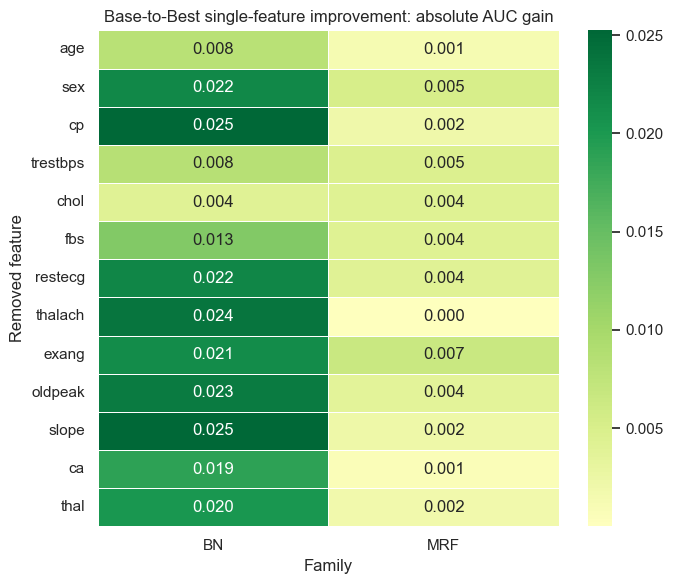

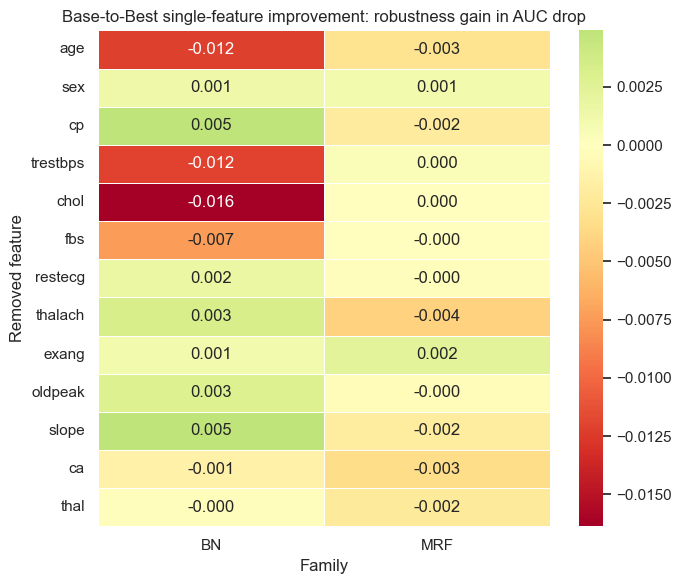

In [13]:
plot_within_family_single_heatmap(
    improvement_df,
    value_col="auc_gain",
    title="Base-to-Best single-feature improvement: absolute AUC gain",
)

plot_within_family_single_heatmap(
    improvement_df,
    value_col="auc_drop_gain",
    title="Base-to-Best single-feature improvement: robustness gain in AUC drop",
)


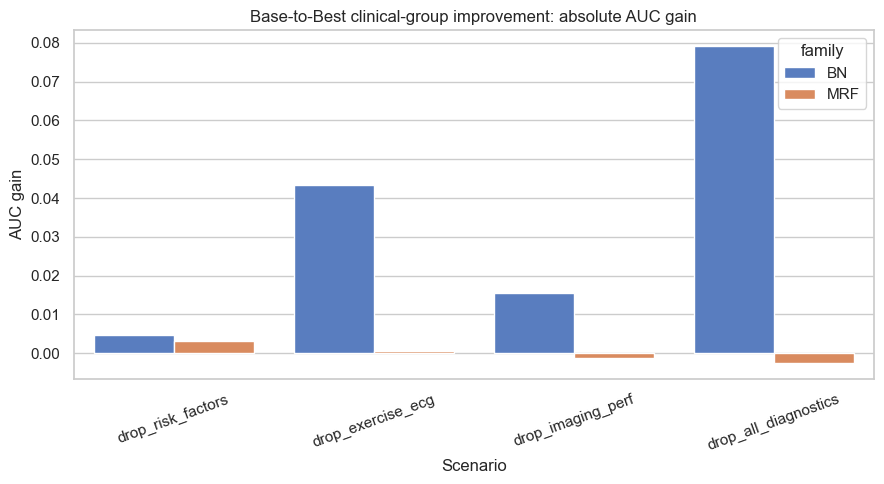

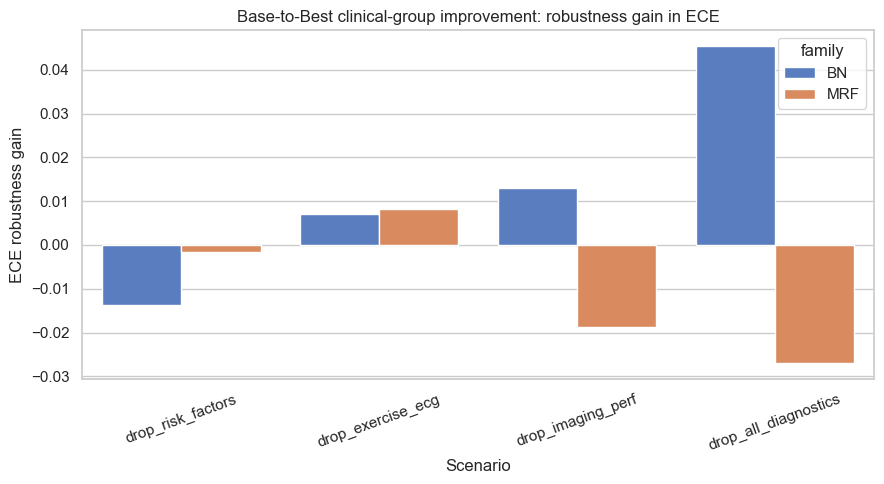

In [14]:
plot_within_family_group_bars(
    improvement_df,
    value_col="auc_gain",
    title="Base-to-Best clinical-group improvement: absolute AUC gain",
    ylabel="AUC gain",
)

plot_within_family_group_bars(
    improvement_df,
    value_col="ece_robust_gain",
    title="Base-to-Best clinical-group improvement: robustness gain in ECE",
    ylabel="ECE robustness gain",
)


## 5. Summary

### Key Findings from Experimental Results

In [15]:
import pandas as pd

# Per-model mean degradation across all scenarios
all_results = pd.concat([single_df, group_df], ignore_index=True)
family_robustness = (
    all_results.groupby(['model'])[['auc_drop', 'brier_increase', 'ece_increase', 'delta_entropy']]
    .mean()
    .reindex(['Base BN', 'Best BN', 'Base MRF', 'Best MRF'])
    .round(4)
)
print('Mean degradation across all missing-evidence scenarios:')
display(family_robustness)

# Most critical single feature per model
print('\nMost critical single feature (largest mean AUC drop) per model:')
worst_per_model = (
    single_df.groupby(['model', 'scenario'])['auc_drop']
    .mean()
    .reset_index()
    .sort_values('auc_drop')
    .groupby('model')
    .first()
    .rename(columns={'scenario': 'worst_feature', 'auc_drop': 'auc_drop'})
)
worst_per_model['worst_feature'] = worst_per_model['worst_feature'].str.replace('drop_', '')
display(worst_per_model.reindex(['Base BN', 'Best BN', 'Base MRF', 'Best MRF']))

Mean degradation across all missing-evidence scenarios:


,auc_drop,brier_increase,ece_increase,delta_entropy
model,,,,
Base BN,-0.0219,0.0071,0.0071,0.0615
Best BN,-0.0200,0.0107,0.0033,0.0633
Base MRF,-0.0194,0.0294,0.0285,0.0242
Best MRF,-0.0212,0.0332,0.0322,0.0103



Most critical single feature (largest mean AUC drop) per model:


,worst_feature,auc_drop
model,,
Base BN,ca,-0.025689
Best BN,ca,-0.027107
Base MRF,ca,-0.023468
Best MRF,ca,-0.026931


### Interpretation

**Feature criticality:**  
The single-feature heatmap reveals structural bottlenecks in each model's graph. In the Base BN (star DAG), removing any feature severs exactly one edge to/from `num`. In the Best BN, the learned multi-hop structure creates alternative inference paths, which can either increase or decrease sensitivity to individual features depending on their position in the DAG.

**Directed vs undirected under missing evidence:**  
Base BN and Base MRF share the same 13-edge graph skeleton. The key difference is that in the BN, removing a symptom node (e.g., `ca`) disconnects the `num → ca` directed edge, while in the MRF the same undirected edge simply becomes absent — but `num` can still receive indirect evidence through shared neighbours. This is visible in the entropy plot: BN entropy increases more strongly when a high-MI feature is removed, while the MRF shows a more diffuse response.

**Uncertainty quantification:**  
Both model families show positive `delta_entropy` under missing evidence (models become more uncertain), which is the correct behaviour for a probabilistic model. This confirms that entropy is a reliable uncertainty signal for clinical use — patients with incomplete test results will receive higher-entropy predictions, flagging them for additional workup.

**Drop-risk-factors is benign:**  
Removing demographic/background features (`age`, `sex`, `fbs`, `chol`, `trestbps`) causes negligible AUC degradation across all models. These features have low individual correlations with `num` (r ≤ 0.28); the diagnostic signal is dominated by the imaging and exercise-test features.

**Imaging loss is critical (`drop_imaging_perf`):**  
Removing `ca` and `thal` causes the largest single-group AUC drop. This matches the EDA finding that these are the two strongest predictors (r=0.52, 0.51). In clinical terms, this suggests that fluoroscopy vessel counts and thalassemia test results are the most non-substitutable inputs for these models.

## 6. Matched-Feature Protocol: BN vs MRF vs GMM

To compare BN, MRF, and GMM fairly, we restrict all three models to the same five continuous clinical measurements:
`age`, `trestbps`, `chol`, `thalach`, `oldpeak`.

- **Matched BN**: 5-feature directed model `age, trestbps, chol -> num -> thalach, oldpeak`
- **Matched MRF**: undirected model on the same 5-feature skeleton
- **GMM**: class-conditional 2-component GMM
- **Missing-test handling for GMM**: exact marginalization over missing dimensions, not imputation

This protocol isolates robustness to missing evidence from differences in feature availability.

In [16]:
from robustness_utils import (
    MATCHED_FEATURES,
    MATCHED_GROUP_REMOVAL,
    MATCHED_MODEL_ORDER,
    MATCHED_SINGLE_FEATURE_REMOVAL,
    get_matched_model_specs,
    load_matched_heart_data,
    model_definition_table,
    plot_group_bars,
    plot_random_missingness_curves,
    plot_single_feature_heatmap,
    run_full_baseline,
    run_missing_scenarios,
    run_random_missingness,
    summarize_baseline_results,
    summarize_random_missingness_results,
    summarize_scenario_results,
)

MATCHED_COLORS = {
    'Matched BN': '#4C72B0',
    'Matched MRF': '#C44E52',
    'GMM': '#7B61FF',
}


In [17]:
matched_df = load_matched_heart_data('heart_disease_cleaned.csv')
matched_model_specs = get_matched_model_specs(gmm_components=2)

print(f'Matched-feature dataset: {matched_df.shape[0]} rows x {matched_df.shape[1]} cols')
print('Matched model definitions:')
display(model_definition_table(matched_model_specs))

matched_baseline_df = run_full_baseline(
    matched_df,
    model_specs=matched_model_specs,
    feature_columns=MATCHED_FEATURES,
)
matched_baseline_summary = summarize_baseline_results(
    matched_baseline_df,
    model_order=MATCHED_MODEL_ORDER,
)
display(matched_baseline_summary[['auc', 'brier', 'log_loss', 'ece', 'mean_entropy', 'mean_variance']])


Matched-feature dataset: 303 rows x 6 cols
Matched model definitions:


,model,family,level,description
0,Matched BN,BN,Matched,5-feature BN on age/trestbps/chol -> num -> th...
1,Matched MRF,MRF,Matched,5-feature MRF on the same skeleton as the matc...
2,GMM,GMM,Matched,Class-conditional 2-component GMM with exact m...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}


,auc,brier,log_loss,ece,mean_entropy,mean_variance
model,,,,,,
Matched BN,0.7520,0.2057,0.6340,0.1491,0.6959,0.1582
Matched MRF,0.7794,0.2101,0.6398,0.1665,0.6312,0.1401
GMM,0.7433,0.2313,0.8665,0.2107,0.5332,0.1214


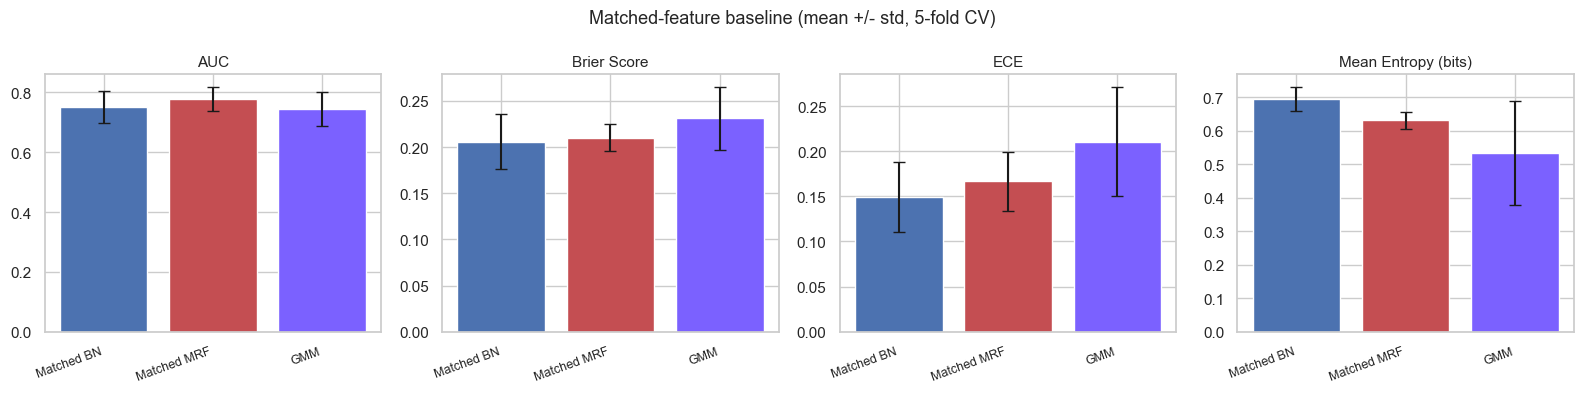

In [18]:
metrics_to_plot = ['auc', 'brier', 'ece', 'mean_entropy']
labels = {
    'auc': 'AUC',
    'brier': 'Brier Score',
    'ece': 'ECE',
    'mean_entropy': 'Mean Entropy (bits)',
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metrics_to_plot):
    means = matched_baseline_df.groupby('model')[metric].mean().reindex(MATCHED_MODEL_ORDER)
    stds = matched_baseline_df.groupby('model')[metric].std().reindex(MATCHED_MODEL_ORDER)
    ax.bar(
        MATCHED_MODEL_ORDER,
        means,
        yerr=stds,
        capsize=4,
        color=[MATCHED_COLORS[m] for m in MATCHED_MODEL_ORDER],
        edgecolor='white',
    )
    ax.set_title(labels[metric], fontsize=11)
    ax.set_xticklabels(MATCHED_MODEL_ORDER, rotation=20, ha='right', fontsize=9)

fig.suptitle('Matched-feature baseline (mean +/- std, 5-fold CV)', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Matched-Feature Missing-Evidence Experiments

We now remove evidence under the shared 5-feature protocol so that BN, MRF, and GMM are evaluated on exactly the same information budget.

In [19]:
matched_single_df = run_missing_scenarios(
    matched_df,
    MATCHED_SINGLE_FEATURE_REMOVAL,
    experiment_name='matched_single_feature',
    model_specs=matched_model_specs,
    feature_columns=MATCHED_FEATURES,
)
matched_single_summary = summarize_scenario_results(matched_single_df)
display(matched_single_summary[['auc', 'auc_drop', 'ece_increase', 'delta_entropy', 'delta_prob_abs']])


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}


auc  auc_drop  ece_increase  delta_entropy  \
scenario      model                                                        
drop_age      GMM          0.7325   -0.0108        0.0008         0.0304   
              Matched BN   0.7663    0.0143       -0.0107         0.0471   
              Matched MRF  0.7716   -0.0078       -0.0064         0.0298   
drop_chol     GMM          0.7558    0.0125       -0.0296         0.0185   
              Matched BN   0.7711    0.0191        0.0057         0.0172   
              Matched MRF  0.7742   -0.0052       -0.0026         0.0109   
drop_oldpeak  GMM          0.7204   -0.0229       -0.0441         0.2024   
              Matched BN   0.7079   -0.0441        0.0016         0.1136   
              Matched MRF  0.7288   -0.0506        0.0442         0.0494   
drop_thalach  GMM          0.7051   -0.0381       -0.0255         0.0962   
              Matched BN   0.6939   -0.0581       -0.0088         0.1224   
              Matched MRF  0.7186   -0.0608        0.0391         0.0525   
drop_trestbps GMM          0.7790    0.0358       -0.0289         0.0215   
              Matched BN   0.7721    0.0201       -0.0041         0.0078   
              Matched MRF  0.7800    0.0006        0.0016         0.0033   

                           delta_prob_abs  
scenario      model                        
drop_age      GMM                  0.0776  
              Matched BN           0.0611  
              Matched MRF          0.0380  
drop_chol     GMM                  0.0525  
              Matched BN           0.0619  
              Matched MRF          0.0378  
drop_oldpeak  GMM                  0.1704  
              Matched BN           0.1185  
              Matched MRF          0.1150  
drop_thalach  GMM                  0.1247  
              Matched BN           0.1459  
              Matched MRF          0.1331  
drop_trestbps GMM                  0.0536  
              Matched BN           0.0372  
              Matched MRF          0.0143

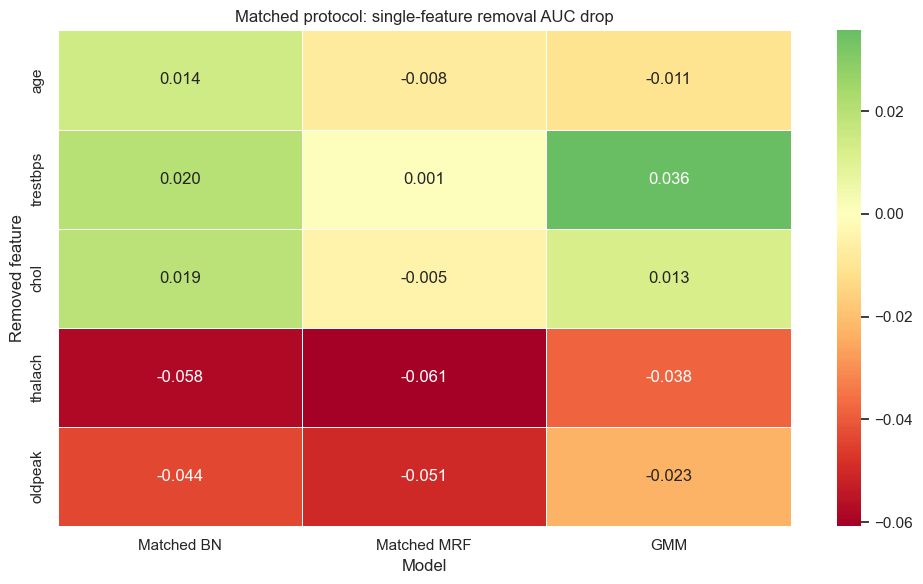

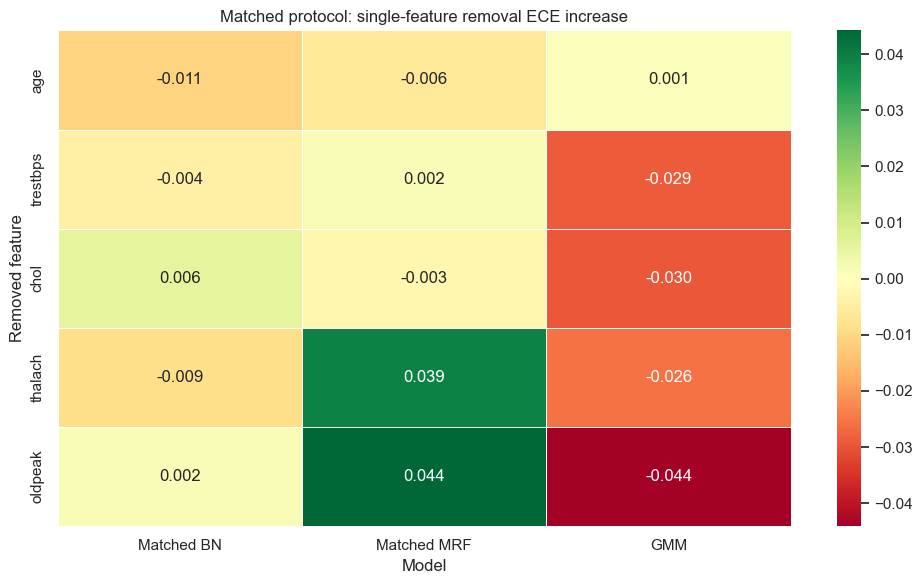

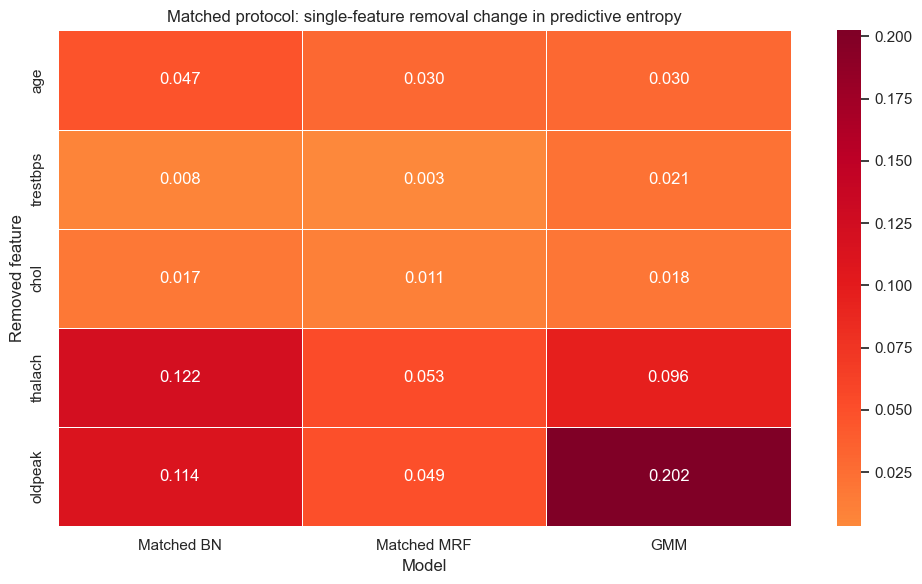

In [20]:
plot_single_feature_heatmap(
    matched_single_df,
    value_col='auc_drop',
    title='Matched protocol: single-feature removal AUC drop',
    model_order=MATCHED_MODEL_ORDER,
    feature_order=MATCHED_FEATURES,
)

plot_single_feature_heatmap(
    matched_single_df,
    value_col='ece_increase',
    title='Matched protocol: single-feature removal ECE increase',
    model_order=MATCHED_MODEL_ORDER,
    feature_order=MATCHED_FEATURES,
)

plot_single_feature_heatmap(
    matched_single_df,
    value_col='delta_entropy',
    title='Matched protocol: single-feature removal change in predictive entropy',
    cmap='YlOrRd',
    center=0.0,
    model_order=MATCHED_MODEL_ORDER,
    feature_order=MATCHED_FEATURES,
)


In [21]:
matched_group_df = run_missing_scenarios(
    matched_df,
    MATCHED_GROUP_REMOVAL,
    experiment_name='matched_group',
    model_specs=matched_model_specs,
    feature_columns=MATCHED_FEATURES,
)
matched_group_summary = summarize_scenario_results(matched_group_df)
display(matched_group_summary[['auc', 'auc_drop', 'ece_increase', 'delta_entropy', 'delta_prob_abs']])


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}


auc  auc_drop  ece_increase  delta_entropy  \
scenario      model                                                        
drop_exercise GMM          0.6062   -0.1371       -0.0621         0.3591   
              Matched BN   0.5576   -0.1944       -0.0173         0.2253   
              Matched MRF  0.6004   -0.1790        0.1085         0.0308   
drop_risk     GMM          0.7743    0.0311       -0.0311         0.0742   
              Matched BN   0.7640    0.0120       -0.0384         0.0507   
              Matched MRF  0.7642   -0.0152       -0.0156         0.0446   

                           delta_prob_abs  
scenario      model                        
drop_exercise GMM                  0.2715  
              Matched BN           0.2212  
              Matched MRF          0.2150  
drop_risk     GMM                  0.1065  
              Matched BN           0.0828  
              Matched MRF          0.0648

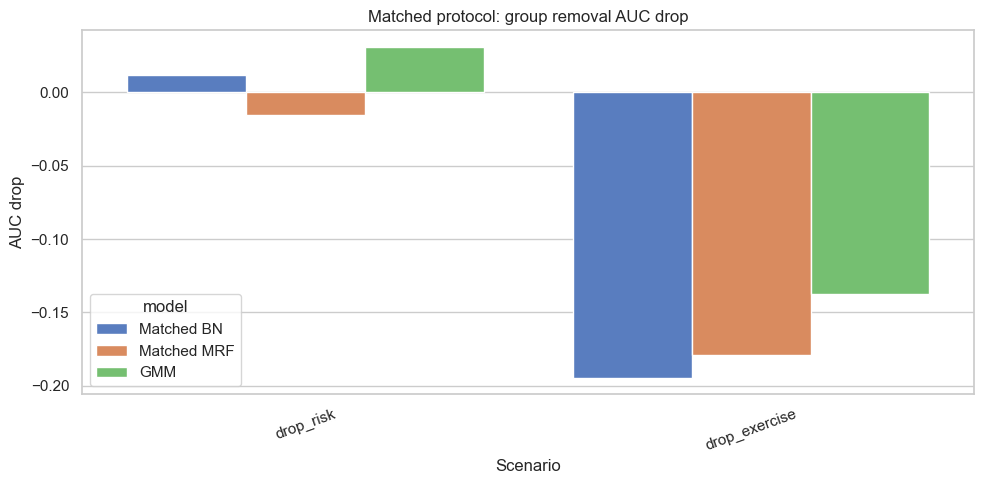

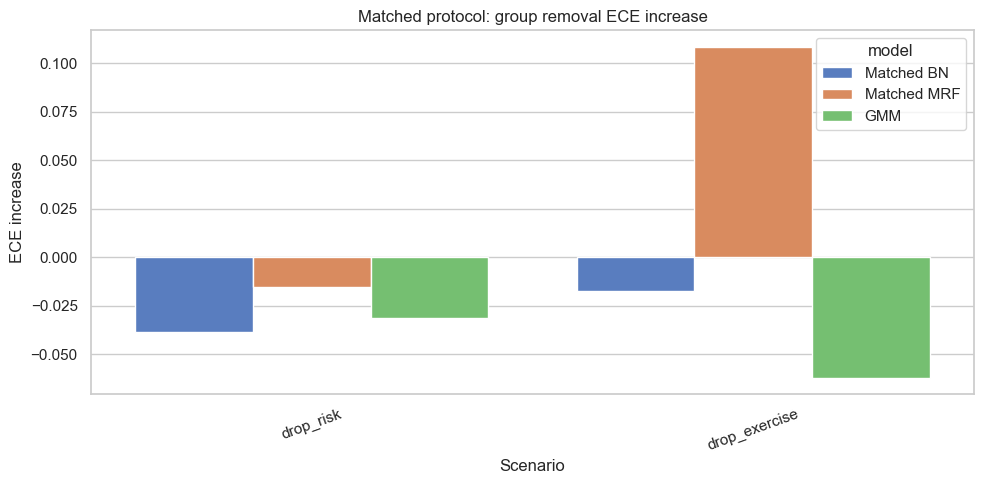

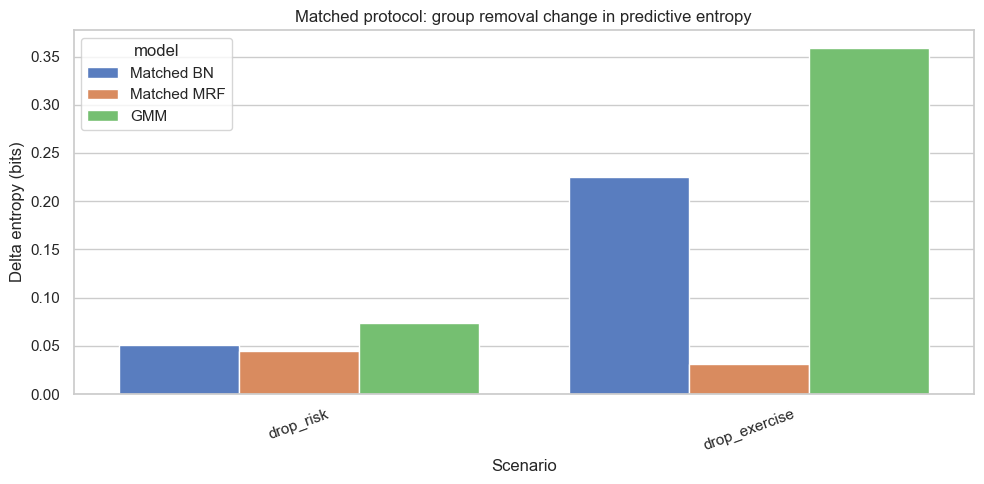

In [22]:
plot_group_bars(
    matched_group_df,
    value_col='auc_drop',
    title='Matched protocol: group removal AUC drop',
    ylabel='AUC drop',
    scenario_order=list(MATCHED_GROUP_REMOVAL.keys()),
    model_order=MATCHED_MODEL_ORDER,
)

plot_group_bars(
    matched_group_df,
    value_col='ece_increase',
    title='Matched protocol: group removal ECE increase',
    ylabel='ECE increase',
    scenario_order=list(MATCHED_GROUP_REMOVAL.keys()),
    model_order=MATCHED_MODEL_ORDER,
)

plot_group_bars(
    matched_group_df,
    value_col='delta_entropy',
    title='Matched protocol: group removal change in predictive entropy',
    ylabel='Delta entropy (bits)',
    scenario_order=list(MATCHED_GROUP_REMOVAL.keys()),
    model_order=MATCHED_MODEL_ORDER,
)


## 8. Random Missingness Under the Matched Protocol

For each test sample, we randomly remove `k` features from the shared 5-feature set and recompute the posterior.

- `k in {0, 1, 2, 3, 4}`
- 20 random masks per fold
- training data remains complete
- GMM continues to handle missing test features via exact marginalization

In [23]:
RANDOM_MISSING_COUNTS = [0, 1, 2, 3, 4]
RANDOM_REPEATS = 20

matched_random_df = run_random_missingness(
    matched_df,
    feature_columns=MATCHED_FEATURES,
    model_specs=matched_model_specs,
    missing_counts=RANDOM_MISSING_COUNTS,
    repeats=RANDOM_REPEATS,
    random_state=42,
)
matched_random_summary = summarize_random_missingness_results(
    matched_random_df,
    metrics=['auc', 'auc_drop', 'brier_increase', 'ece_increase', 'delta_entropy'],
    model_order=MATCHED_MODEL_ORDER,
)
display(matched_random_summary)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'trestbps': 'N', 'chol': 'N', 'thalach': 'N', 'oldpeak': 'N', 'num': 'N'}


auc  auc_drop  brier_increase  ece_increase  \
n_removed model                                                         
0         Matched BN   0.7520    0.0000          0.0000        0.0000   
          Matched MRF  0.7794    0.0000          0.0000        0.0000   
          GMM          0.7433    0.0000          0.0000        0.0000   
1         Matched BN   0.7464   -0.0056         -0.0003       -0.0054   
          Matched MRF  0.7552   -0.0242          0.0152        0.0227   
          GMM          0.7381   -0.0051         -0.0064       -0.0287   
2         Matched BN   0.7239   -0.0282          0.0072       -0.0106   
          Matched MRF  0.7251   -0.0543          0.0361        0.0472   
          GMM          0.7162   -0.0271         -0.0048       -0.0473   
3         Matched BN   0.6961   -0.0559          0.0149       -0.0246   
          Matched MRF  0.6903   -0.0891          0.0556        0.0623   
          GMM          0.7018   -0.0415         -0.0079       -0.0713   
4         Matched BN   0.6289   -0.1232          0.0288       -0.0470   
          Matched MRF  0.6234   -0.1560          0.0803        0.0803   
          GMM          0.6511   -0.0922          0.0012       -0.0933   

                       delta_entropy  
n_removed model                       
0         Matched BN          0.0000  
          Matched MRF         0.0000  
          GMM                 0.0000  
1         Matched BN          0.0641  
          Matched MRF         0.0323  
          GMM                 0.0756  
2         Matched BN          0.1236  
          Matched MRF         0.0486  
          GMM                 0.1572  
3         Matched BN          0.1858  
          Matched MRF         0.0718  
          GMM                 0.2563  
4         Matched BN          0.2429  
          Matched MRF         0.0825  
          GMM                 0.3540

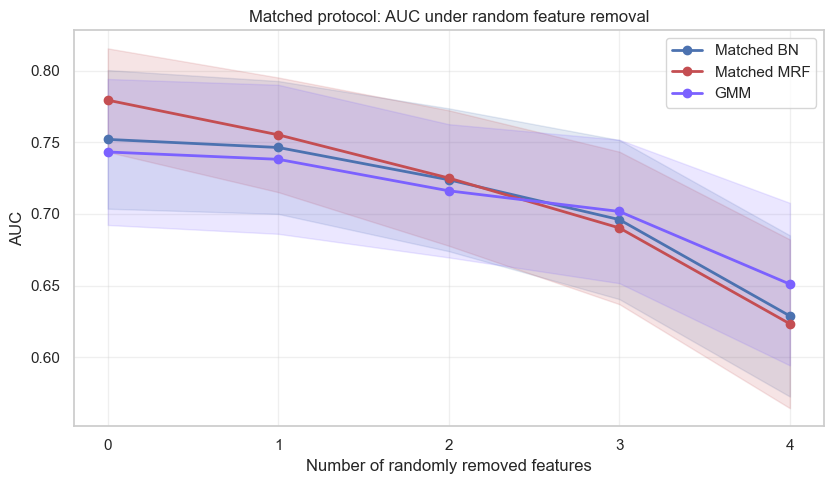

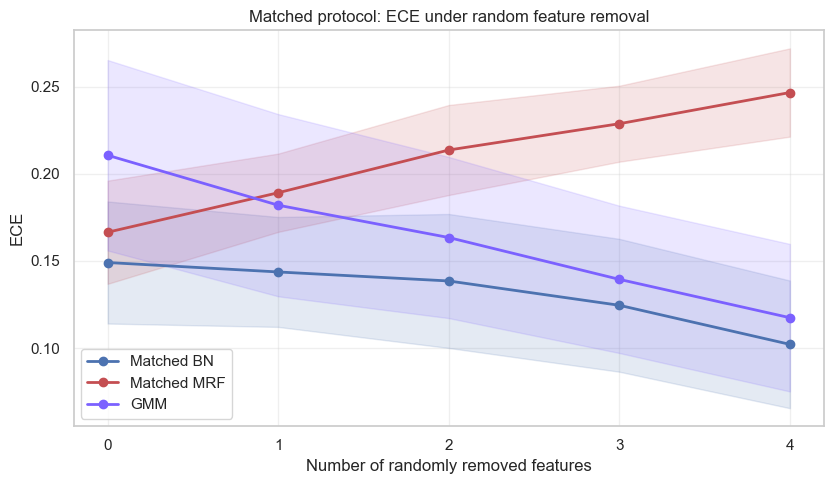

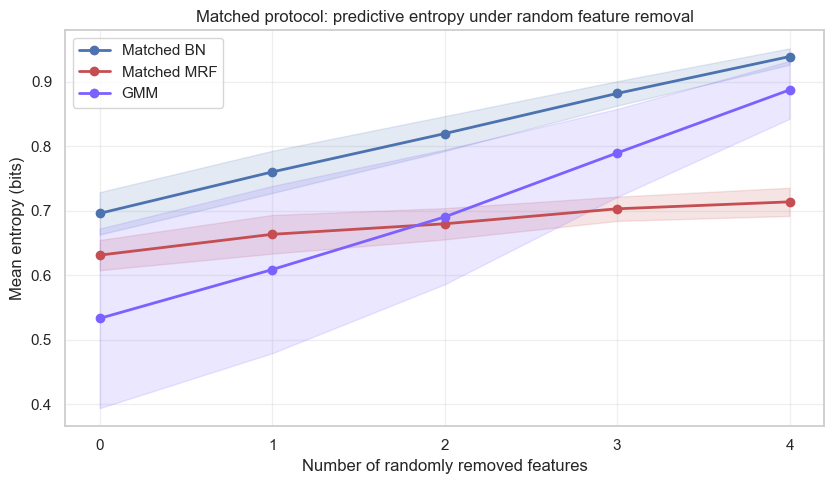

In [24]:
plot_random_missingness_curves(
    matched_random_df,
    value_col='auc',
    title='Matched protocol: AUC under random feature removal',
    ylabel='AUC',
    model_order=MATCHED_MODEL_ORDER,
)

plot_random_missingness_curves(
    matched_random_df,
    value_col='ece',
    title='Matched protocol: ECE under random feature removal',
    ylabel='ECE',
    model_order=MATCHED_MODEL_ORDER,
)

plot_random_missingness_curves(
    matched_random_df,
    value_col='mean_entropy',
    title='Matched protocol: predictive entropy under random feature removal',
    ylabel='Mean entropy (bits)',
    model_order=MATCHED_MODEL_ORDER,
)


## 9. Matched-Feature Interpretation

This extension complements the original 13-feature BN/MRF robustness study.

- The **original protocol** still answers how the graph-based models behave when all clinical variables are available.
- The **matched protocol** isolates the model-family comparison by giving BN, MRF, and GMM access to the same five measurements.
- The **random missingness curves** reveal how quickly each model degrades as evidence becomes sparse, while the entropy plots show whether uncertainty rises appropriately.